In [2]:
import warnings
warnings.filterwarnings("ignore")

import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress, kendalltau, theilslopes
from statsmodels.tsa.stattools import adfuller

from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    confusion_matrix, classification_report
)
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.multioutput import MultiOutputRegressor
from sklearn.linear_model import ElasticNet, LogisticRegression
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

In [3]:
# ========= ELEGANT GLOBAL PLOT STYLE (add once after imports) =========
from cycler import cycler
from matplotlib.ticker import MultipleLocator
import calendar

ELEGANT_PALETTE = [
    "#4C78A8", "#F58518", "#54A24B", "#E45756",
    "#72B7B2", "#B279A2", "#9D755D", "#BAB0AC"
]

sns.set_theme(context="talk", style="whitegrid")

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 400,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "figure.facecolor": "white",
    "axes.facecolor": "#FBFCFF",
    "axes.edgecolor": "#D0D7E2",
    "axes.linewidth": 1.0,
    "axes.grid": True,
    "axes.grid.axis": "y",
    "grid.color": "#D8DEE9",
    "grid.linestyle": "--",
    "grid.linewidth": 0.8,
    "grid.alpha": 0.65,
    "font.size": 11,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
    "xtick.labelsize": 10.5,
    "ytick.labelsize": 10.5,
    "legend.frameon": False,
    "legend.fontsize": 10.5,
    "lines.linewidth": 2.4,
    "lines.markersize": 6,
    "axes.prop_cycle": cycler(color=ELEGANT_PALETTE),
})

MONTH_LABELS = [calendar.month_abbr[i] for i in range(1, 13)]

def polish_ax(ax, title=None, xlabel=None, ylabel=None):
    if title is not None:
        ax.set_title(title, pad=12, weight="bold")
    if xlabel is not None:
        ax.set_xlabel(xlabel, labelpad=8)
    if ylabel is not None:
        ax.set_ylabel(ylabel, labelpad=8)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#D0D7E2")
    ax.spines["bottom"].set_color("#D0D7E2")
    ax.grid(axis="y", linestyle="--", alpha=0.65)
    ax.grid(axis="x", visible=False)
    ax.set_axisbelow(True)

def finish_figure(fig, save_path=None):
    fig.tight_layout()
    if save_path is not None:
        fig.savefig(save_path, dpi=400, bbox_inches="tight", facecolor="white")
    plt.show()

In [4]:
from pathlib import Path
import pandas as pd

# set working directory (current folder)
DATA_DIR = Path(".")

# load processed datasets (CSV files)
df_monthly = pd.read_csv(DATA_DIR / "weather_monthly_station.csv")
df_annual  = pd.read_csv(DATA_DIR / "weather_annual_station.csv")
df_model   = pd.read_csv(DATA_DIR / "weather_model_t1.csv", parse_dates=["date"])

# load daily dataset from memory OR file
if "df_stat" in globals():
    df_daily = df_stat.copy()
elif "df_clean" in globals():
    df_daily = df_clean.copy()
else:
    # fallback if you saved it as CSV
    df_daily = pd.read_csv(
        DATA_DIR / "weather_daily_clean_processed.csv",
        parse_dates=["date"]
    )

# quick check
print("Daily:", df_daily.shape)
print("Monthly:", df_monthly.shape)
print("Annual:", df_annual.shape)
print("Model:", df_model.shape)

print("\nColumns (daily):", df_daily.columns.tolist())
print("\nColumns (model):", df_model.columns[:20].tolist())

Daily: (543839, 108)
Monthly: (17868, 8)
Annual: (1489, 6)
Model: (542754, 73)

Columns (daily): ['date', 'station', 'rainfall', 'sunshine', 'humidity', 'temperature', 'was_missing_row', 'year', 'month', 'day', 'dayofyear', 'weekofyear', 'quarter', 'season', 'is_monsoon', 'rainfall_flag_invalid', 'humidity_flag_invalid', 'sunshine_flag_invalid', 'temperature_flag_invalid', 'temperature_imputed_flag', 'humidity_imputed_flag', 'sunshine_imputed_flag', 'rainfall_imputed_flag', 'month_sin', 'month_cos', 'doy_sin', 'doy_cos', 'station_mean_rainfall', 'station_mean_temperature', 'station_mean_humidity', 'station_mean_sunshine', 'rainfall_month_clim', 'temperature_month_clim', 'humidity_month_clim', 'sunshine_month_clim', 'rainfall_anomaly', 'temperature_anomaly', 'humidity_anomaly', 'sunshine_anomaly', 'rainfall_lag1', 'rainfall_lag3', 'rainfall_lag7', 'rainfall_lag14', 'rainfall_lag30', 'temperature_lag1', 'temperature_lag3', 'temperature_lag7', 'temperature_lag14', 'temperature_lag30', 'hu

In [5]:
##Basic cleaning checks on the loaded datasets
# make sure station format is consistent
for _df in [df_daily, df_monthly, df_annual, df_model]:
    _df["station"] = (
        _df["station"]
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace(r"\s+", " ", regex=True)
    )

# ensure date type
if "date" in df_daily.columns:
    df_daily["date"] = pd.to_datetime(df_daily["date"])

df_model["date"] = pd.to_datetime(df_model["date"])

print("Unique stations in daily:", df_daily["station"].nunique())
print("Unique stations in monthly:", df_monthly["station"].nunique())
print("Unique stations in annual:", df_annual["station"].nunique())
print("Unique stations in model:", df_model["station"].nunique())

Unique stations in daily: 35
Unique stations in monthly: 35
Unique stations in annual: 35
Unique stations in model: 35


In [6]:

weather_cols = ["rainfall", "temperature", "humidity", "sunshine"]

for col in weather_cols:
    if col in df_daily.columns:
        df_daily[col] = pd.to_numeric(df_daily[col], errors="coerce")

In [7]:
###Create folders for outputs
os.makedirs("results/figures", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)

In [8]:
###Statistical representation tables
###Overall descriptive statistics
overall_summary = (
    df_daily[weather_cols]
    .agg(["count", "mean", "median", "std", "min", "max", "skew"])
    .T
    .reset_index()
    .rename(columns={"index": "variable"})
)

overall_summary

,variable,count,mean,median,std,min,max,skew
0,rainfall,543839.0,6.732987,0.0,19.366711,0.0,590.0,5.763813
1,temperature,543839.0,25.570680,26.9,4.166981,0.0,37.8,-0.810754
2,humidity,543839.0,79.848704,81.0,8.937966,10.0,100.0,-0.852749
3,sunshine,543839.0,6.279401,7.2,3.348796,0.0,22.2,-0.555370


In [9]:
overall_summary.to_csv("results/tables/overall_summary.csv", index=False)

In [10]:
##Station-wise descriptive statistics
station_summary = (
    df_daily.groupby("station")[weather_cols]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

station_summary.head()

rainfall                                         temperature                                         humidity                                           sunshine                   \
              count      mean median        std  min    max       count       mean median       std   min   max    count       mean median        std   min    max    count      mean median   
station                                                                                                                                                                                        
ambaganctg     5844  8.168378    0.0  24.554056  0.0  438.0        5844  26.174076   27.3  3.567862  13.7  33.6     5844  79.419233   81.0   9.770031  33.0  100.0     5844  6.224120    7.3   
barisal       20819  5.645972    0.0  15.608230  0.0  324.0       20819  25.486149   27.0  4.183174  10.9  37.8    20819  83.132402   83.0   7.278189  45.0  100.0    20819  6.452815    7.5   
bhola         15705  6.061318    0.0  16.510027  0.0  292.0       15705  25.574995   27.1  4.094204  11.6  32.7    15705  83.614390   84.0   6.537456  57.0  100.0    15705  5.372583    6.1   
bogra         23010  4.789937    0.0  14.432534  0.0  279.0       23010  25.248424   26.7  4.597010   0.0  37.8    23010  77.296432   79.0  10.892736  23.0  100.0    23010  6.561326    7.5   
chandpur      17166  6.016370    0.0  17.456594  0.0  334.0       17166  25.898979   27.3  4.005632  12.0  33.4    17166  79.950891   80.0   7.350323  44.0  100.0    17166  5.516268    6.3   

                                 
                 std  min   max  
station                          
ambaganctg  3.385425  0.0  11.9  
barisal     3.427864  0.0  13.5  
bhola       3.085717  0.0  12.1  
bogra       3.457704  0.0  13.8  
chandpur    3.071832  0.0  11.8

In [11]:
station_summary.to_csv("results/tables/station_summary.csv")

In [12]:
###Seasonal descriptive statistics
season_summary = (
    df_daily.groupby("season")[weather_cols]
    .agg(["mean", "median", "std", "min", "max"])
)

season_summary

rainfall                               temperature                                humidity                                sunshine                            
                   mean median        std  min    max        mean median       std   min   max       mean median       std   min    max      mean median       std  min   max
season                                                                                                                                                                       
monsoon       14.411144    3.0  27.208362  0.0  590.0   28.498286   28.6  1.428008  19.8  36.6  85.823639   86.0  5.639502  33.0  100.0  4.428741    4.2  3.403073  0.0  15.8
post_monsoon   3.795262    0.0  15.661063  0.0  403.0   25.513746   25.8  2.623605   0.0  37.8  81.086380   81.0  6.367110  43.0  100.0  7.107668    8.2  3.113649  0.0  13.8
pre_monsoon    4.688100    0.0  14.344963  0.0  328.0   27.450332   27.7  2.559172   0.0  37.8  75.030064   77.0  9.648092  10.0  100.0  7.373331    8.2  2.920909  0.0  14.2
winter         0.422941    0.0   3.466912  0.0  229.0   19.734730   19.7  2.634813   0.0  37.8  75.846769   76.0  8.309574  24.0  100.0  7.106267    7.9  2.735611  0.0  22.2

In [13]:
season_summary.to_csv("results/tables/season_summary.csv")

In [14]:
##Monthly climatology summary
monthly_climatology = (
    df_monthly.groupby("month", as_index=False)
    .agg(
        rainfall_mean=("rainfall_sum", "mean"),
        temperature_mean=("temperature_mean", "mean"),
        humidity_mean=("humidity_mean", "mean"),
        sunshine_mean=("sunshine_sum", "mean")
    )
)

monthly_climatology

,month,rainfall_mean,temperature_mean,humidity_mean,sunshine_mean
0,1,7.333062,18.231110,76.697894,211.728717
1,2,19.793264,21.390780,72.009732,216.029872
2,3,44.506071,25.574374,70.589630,241.577985
3,4,114.946246,28.091669,75.124037,229.540826
4,5,271.852874,28.705642,79.379558,207.227629
5,6,473.290920,28.673951,84.945662,127.982559
6,7,537.446575,28.403844,86.627962,120.634923
7,8,420.795165,28.539902,86.030081,141.373633
8,9,326.626850,28.377207,85.657160,150.315306
9,10,195.875863,27.240327,83.166902,206.173956


In [15]:
monthly_climatology.to_csv("results/tables/monthly_climatology.csv", index=False)

In [16]:
##Annual national summary
national_annual = (
    df_annual.groupby("year", as_index=False)
    .agg(
        rainfall_mean=("rainfall_sum", "mean"),
        temperature_mean=("temperature_mean", "mean"),
        humidity_mean=("humidity_mean", "mean"),
        sunshine_mean=("sunshine_sum", "mean")
    )
)

national_annual.head()

,year,rainfall_mean,temperature_mean,humidity_mean,sunshine_mean
0,1961,3079.054,25.304258,79.609693,2682.268
1,1962,2312.350,25.115879,77.008630,2874.130
2,1963,2779.800,25.018301,78.547945,2773.240
3,1964,3047.000,25.173913,79.049219,2540.024
4,1965,3060.000,24.890619,78.504241,2622.300


In [17]:
national_annual.to_csv("results/tables/national_annual_summary.csv", index=False)

In [18]:
##Station coverage analysis
coverage = (
    df_annual.groupby("station")
    .agg(
        start_year=("year", "min"),
        end_year=("year", "max"),
        n_years=("year", "nunique")
    )
    .reset_index()
    .sort_values(["start_year", "station"])
)

coverage

,station,start_year,end_year,n_years
3,bogra,1961,2023,63
5,chittagong,1961,2023,63
8,coxsbazar,1961,2023,63
9,dhaka,1961,2023,63
32,sylhet,1961,2023,63
1,barisal,1967,2023,57
15,jessore,1969,2023,55
4,chandpur,1977,2023,47
29,sitakunda,1977,2023,47
34,teknaf,1977,2023,47


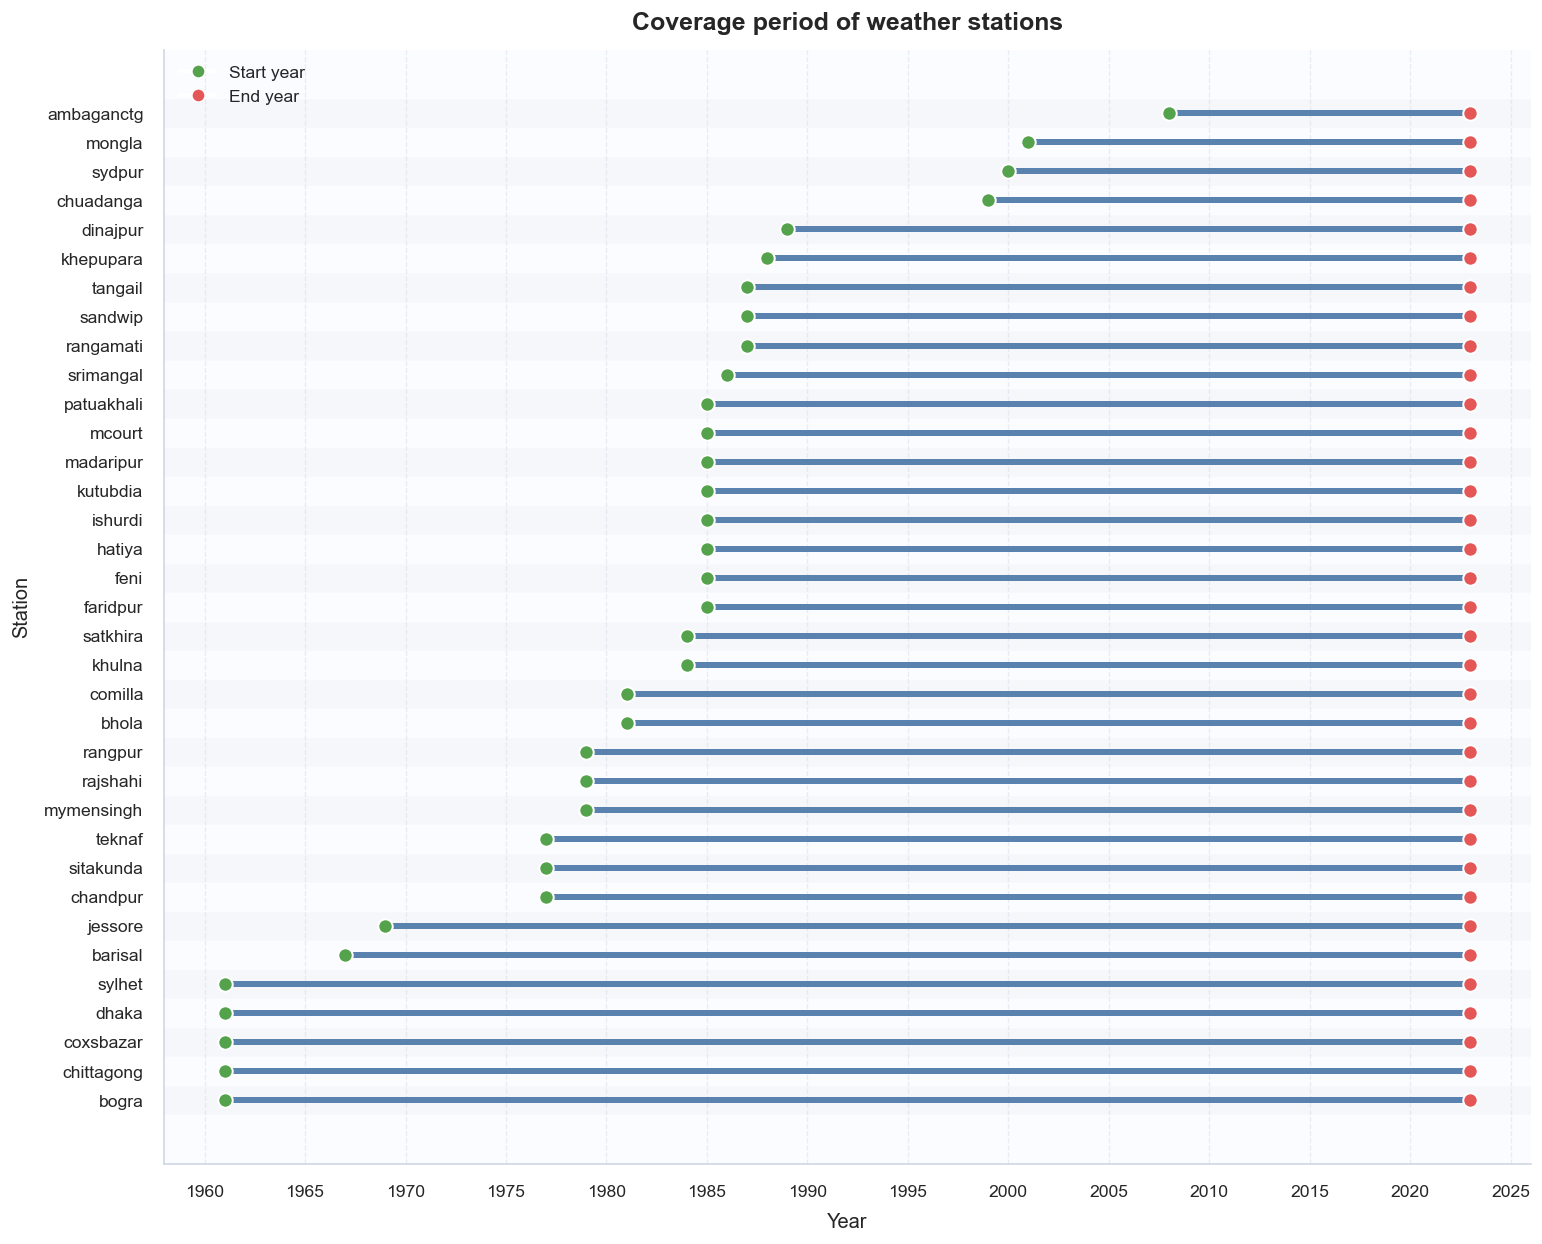

In [19]:
coverage_plot = coverage.sort_values(["start_year", "station"]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(13, 10.5))

for i, row in coverage_plot.iterrows():
    if i % 2 == 0:
        ax.axhspan(i - 0.45, i + 0.45, color="#F5F7FB", zorder=0)

    ax.hlines(
        y=i,
        xmin=row["start_year"],
        xmax=row["end_year"],
        color="#4C78A8",
        linewidth=3.6,
        alpha=0.92,
        zorder=2
    )
    ax.scatter(
        row["start_year"], i,
        s=75, color="#54A24B",
        edgecolor="white", linewidth=1.2, zorder=3
    )
    ax.scatter(
        row["end_year"], i,
        s=75, color="#E45756",
        edgecolor="white", linewidth=1.2, zorder=3
    )

ax.set_yticks(range(len(coverage_plot)))
ax.set_yticklabels(coverage_plot["station"])
ax.set_xlim(coverage_plot["start_year"].min() - 3, coverage_plot["end_year"].max() + 3)
ax.xaxis.set_major_locator(MultipleLocator(5))

start_handle = plt.Line2D([0], [0], marker='o', color='w', label='Start year',
                          markerfacecolor="#54A24B", markeredgecolor="white", markersize=8)
end_handle = plt.Line2D([0], [0], marker='o', color='w', label='End year',
                        markerfacecolor="#E45756", markeredgecolor="white", markersize=8)
ax.legend(handles=[start_handle, end_handle], loc="upper left")

polish_ax(ax, "Coverage period of weather stations", "Year", "Station")
ax.grid(axis="x", linestyle="--", alpha=0.55)
ax.grid(axis="y", visible=False)

finish_figure(fig, "results/figures/station_coverage.png")

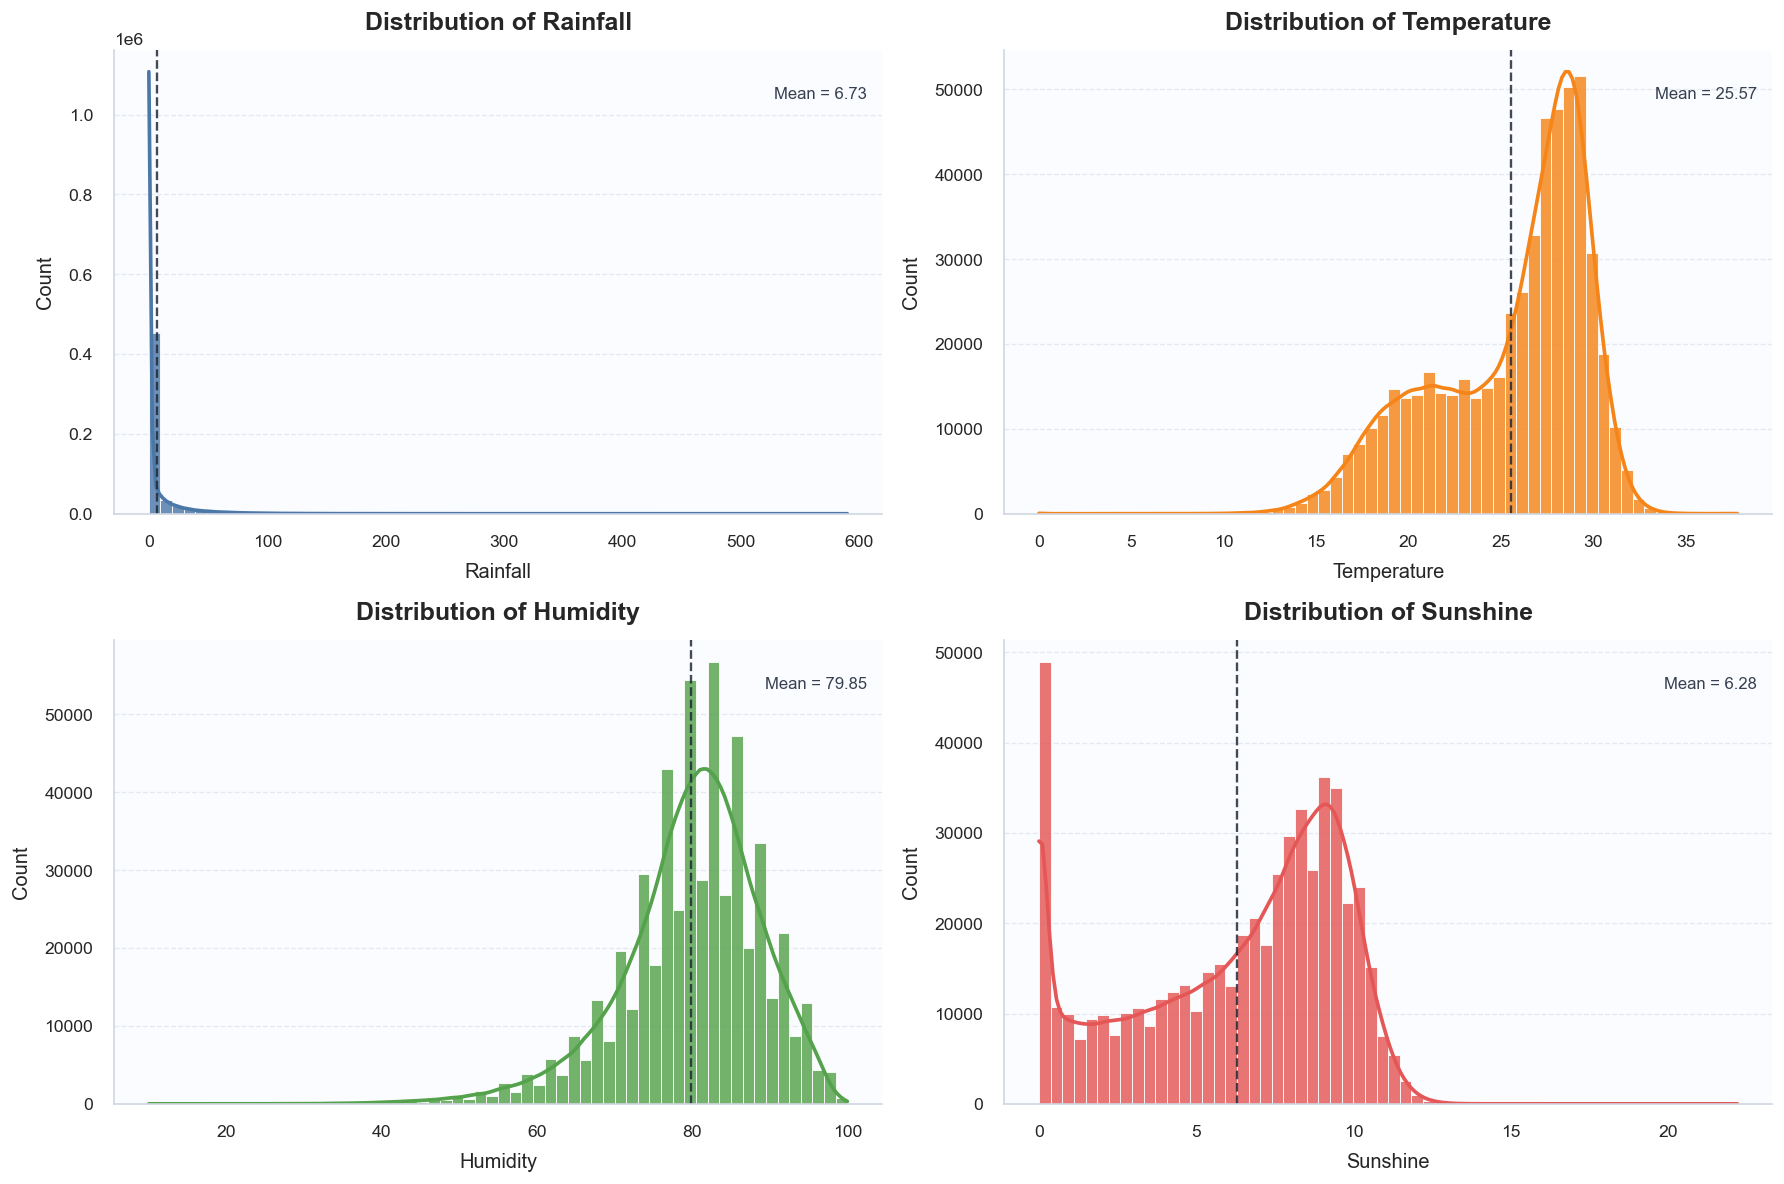

In [20]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
hist_colors = ["#4C78A8", "#F58518", "#54A24B", "#E45756"]

for ax, col, color in zip(axes.flatten(), weather_cols, hist_colors):
    series = df_daily[col].dropna()

    sns.histplot(
        series,
        bins=60,
        kde=True,
        color=color,
        alpha=0.82,
        edgecolor="white",
        linewidth=0.5,
        line_kws={"linewidth": 2.2},
        ax=ax
    )
    ax.axvline(series.mean(), color="#1F2937", linestyle="--", linewidth=1.4, alpha=0.85)
    polish_ax(ax, f"Distribution of {col.replace('_', ' ').title()}", col.replace("_", " ").title(), "Count")
    ax.text(
        0.98, 0.92, f"Mean = {series.mean():.2f}",
        transform=ax.transAxes, ha="right", va="top",
        fontsize=10, color="#374151"
    )

finish_figure(fig, "results/figures/distributions_all_variables.png")

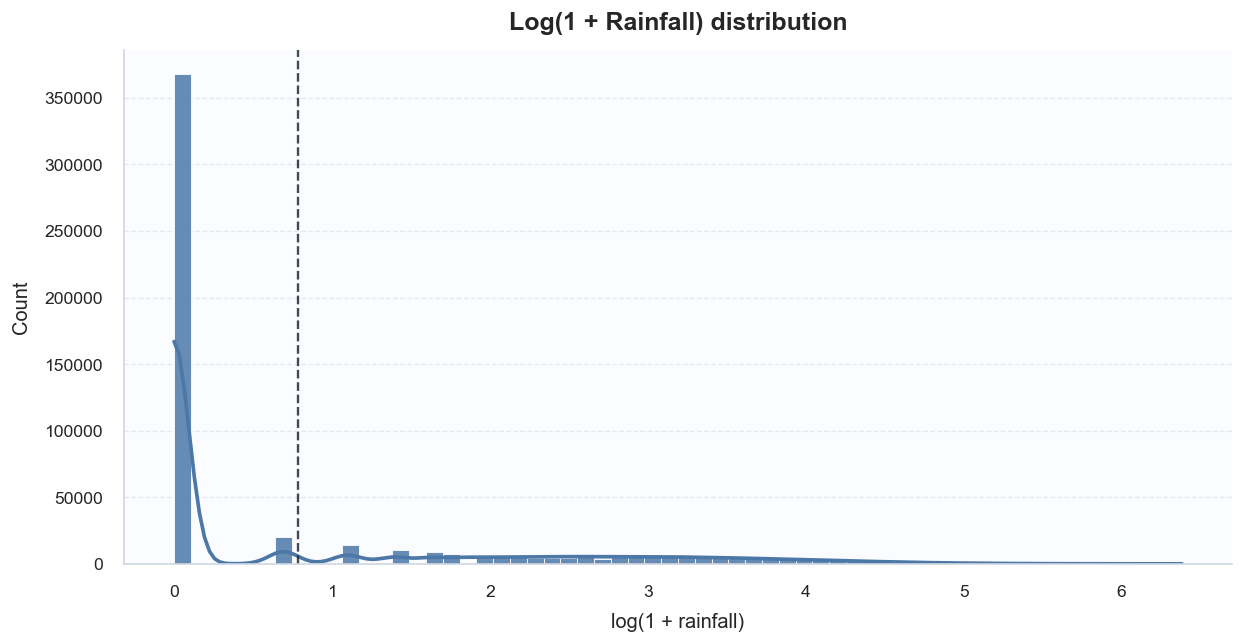

In [21]:
fig, ax = plt.subplots(figsize=(10.5, 5.5))
log_rain = np.log1p(df_daily["rainfall"].dropna())

sns.histplot(
    log_rain,
    bins=60,
    kde=True,
    color="#4C78A8",
    alpha=0.85,
    edgecolor="white",
    linewidth=0.5,
    line_kws={"linewidth": 2.2},
    ax=ax
)

ax.axvline(log_rain.mean(), color="#1F2937", linestyle="--", linewidth=1.4, alpha=0.85)
polish_ax(ax, "Log(1 + Rainfall) distribution", "log(1 + rainfall)", "Count")

finish_figure(fig, "results/figures/rainfall_log_distribution.png")

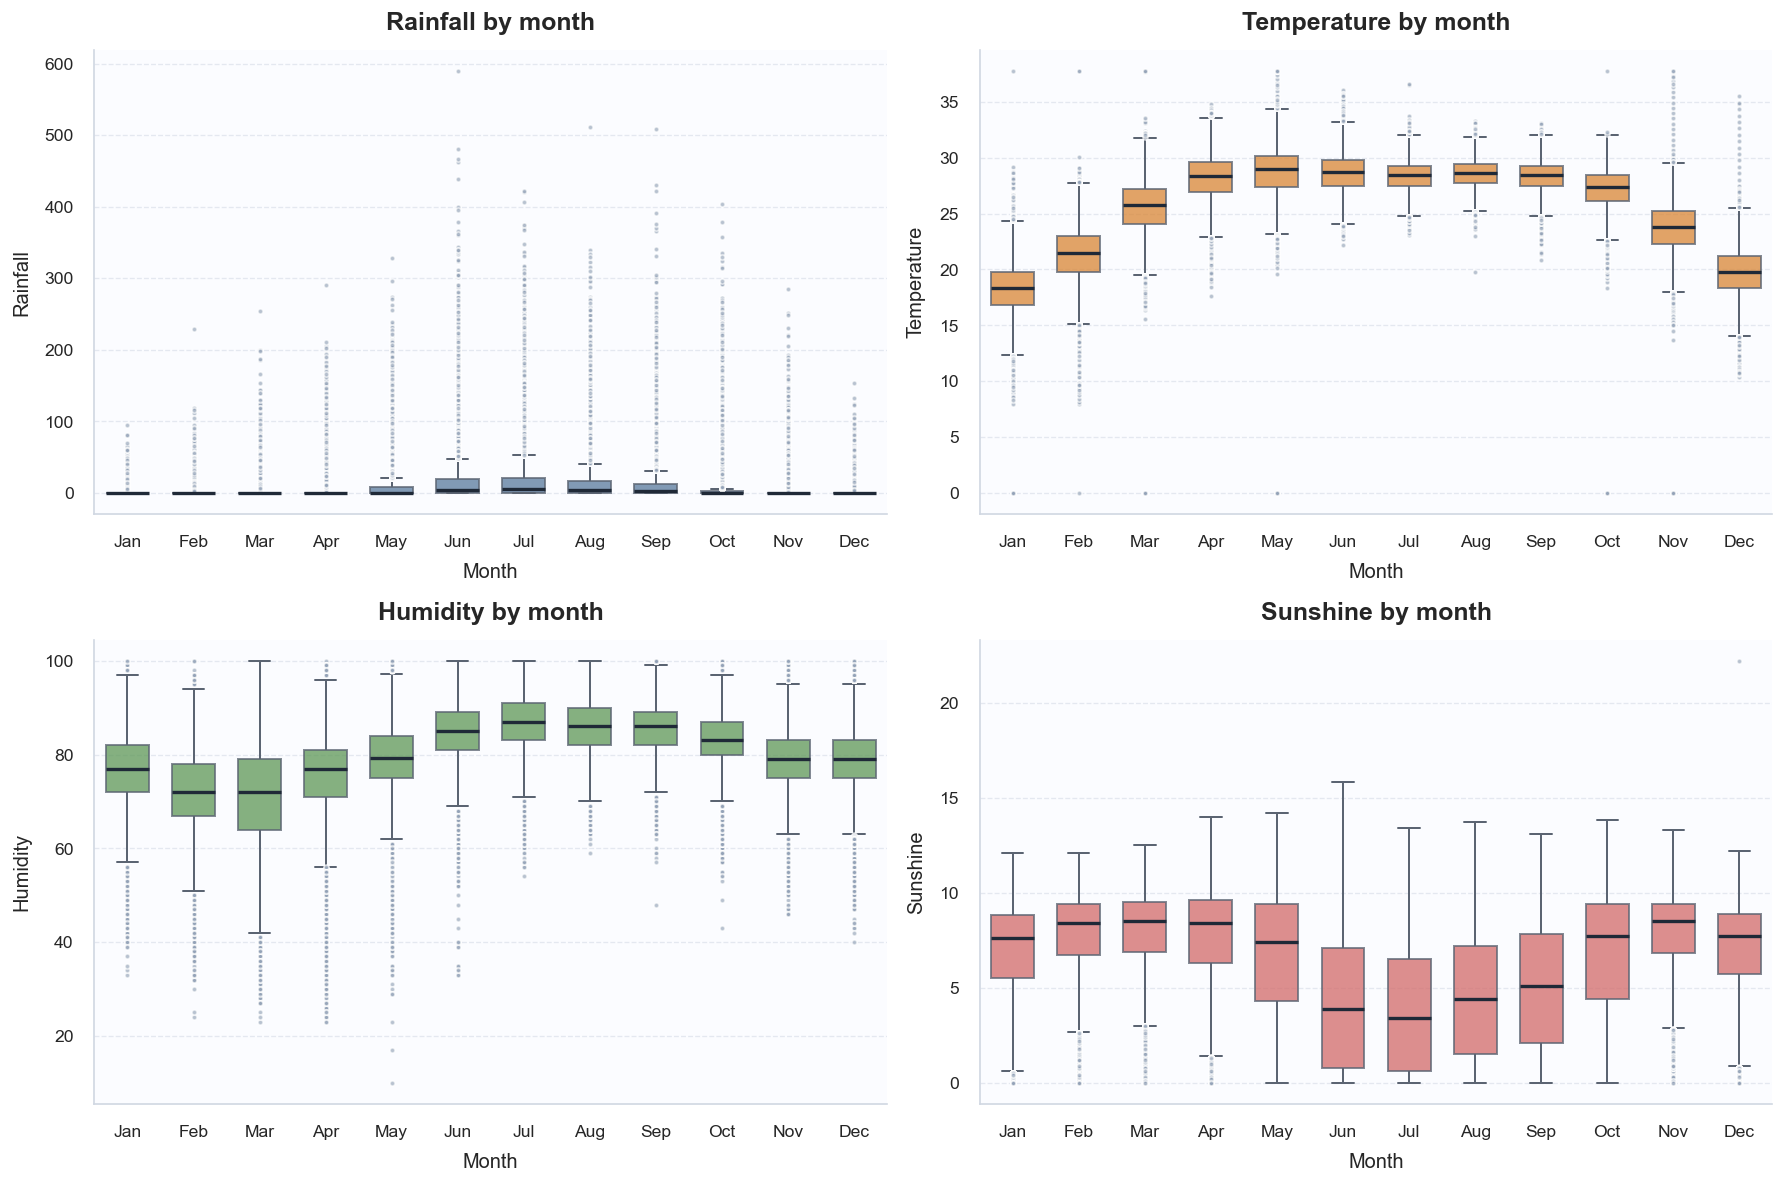

In [22]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

box_specs = [
    ("rainfall", "Rainfall by month", "#4C78A8"),
    ("temperature", "Temperature by month", "#F58518"),
    ("humidity", "Humidity by month", "#54A24B"),
    ("sunshine", "Sunshine by month", "#E45756"),
]

for ax, (col, title, color) in zip(axes.flatten(), box_specs):
    sns.boxplot(
        data=df_daily,
        x="month",
        y=col,
        color=color,
        width=0.65,
        fliersize=2.5,
        linewidth=1.2,
        boxprops=dict(alpha=0.75, edgecolor="#5B6472"),
        medianprops=dict(color="#1F2937", linewidth=2),
        whiskerprops=dict(color="#5B6472", linewidth=1.2),
        capprops=dict(color="#5B6472", linewidth=1.2),
        flierprops=dict(
            marker='o',
            markerfacecolor="#94A3B8",
            markeredgecolor="white",
            markersize=3,
            alpha=0.65
        ),
        ax=ax
    )
    ax.set_xticks(range(12))
    ax.set_xticklabels(MONTH_LABELS)
    polish_ax(ax, title, "Month", col.replace("_", " ").title())

finish_figure(fig, "results/figures/monthly_boxplots.png")

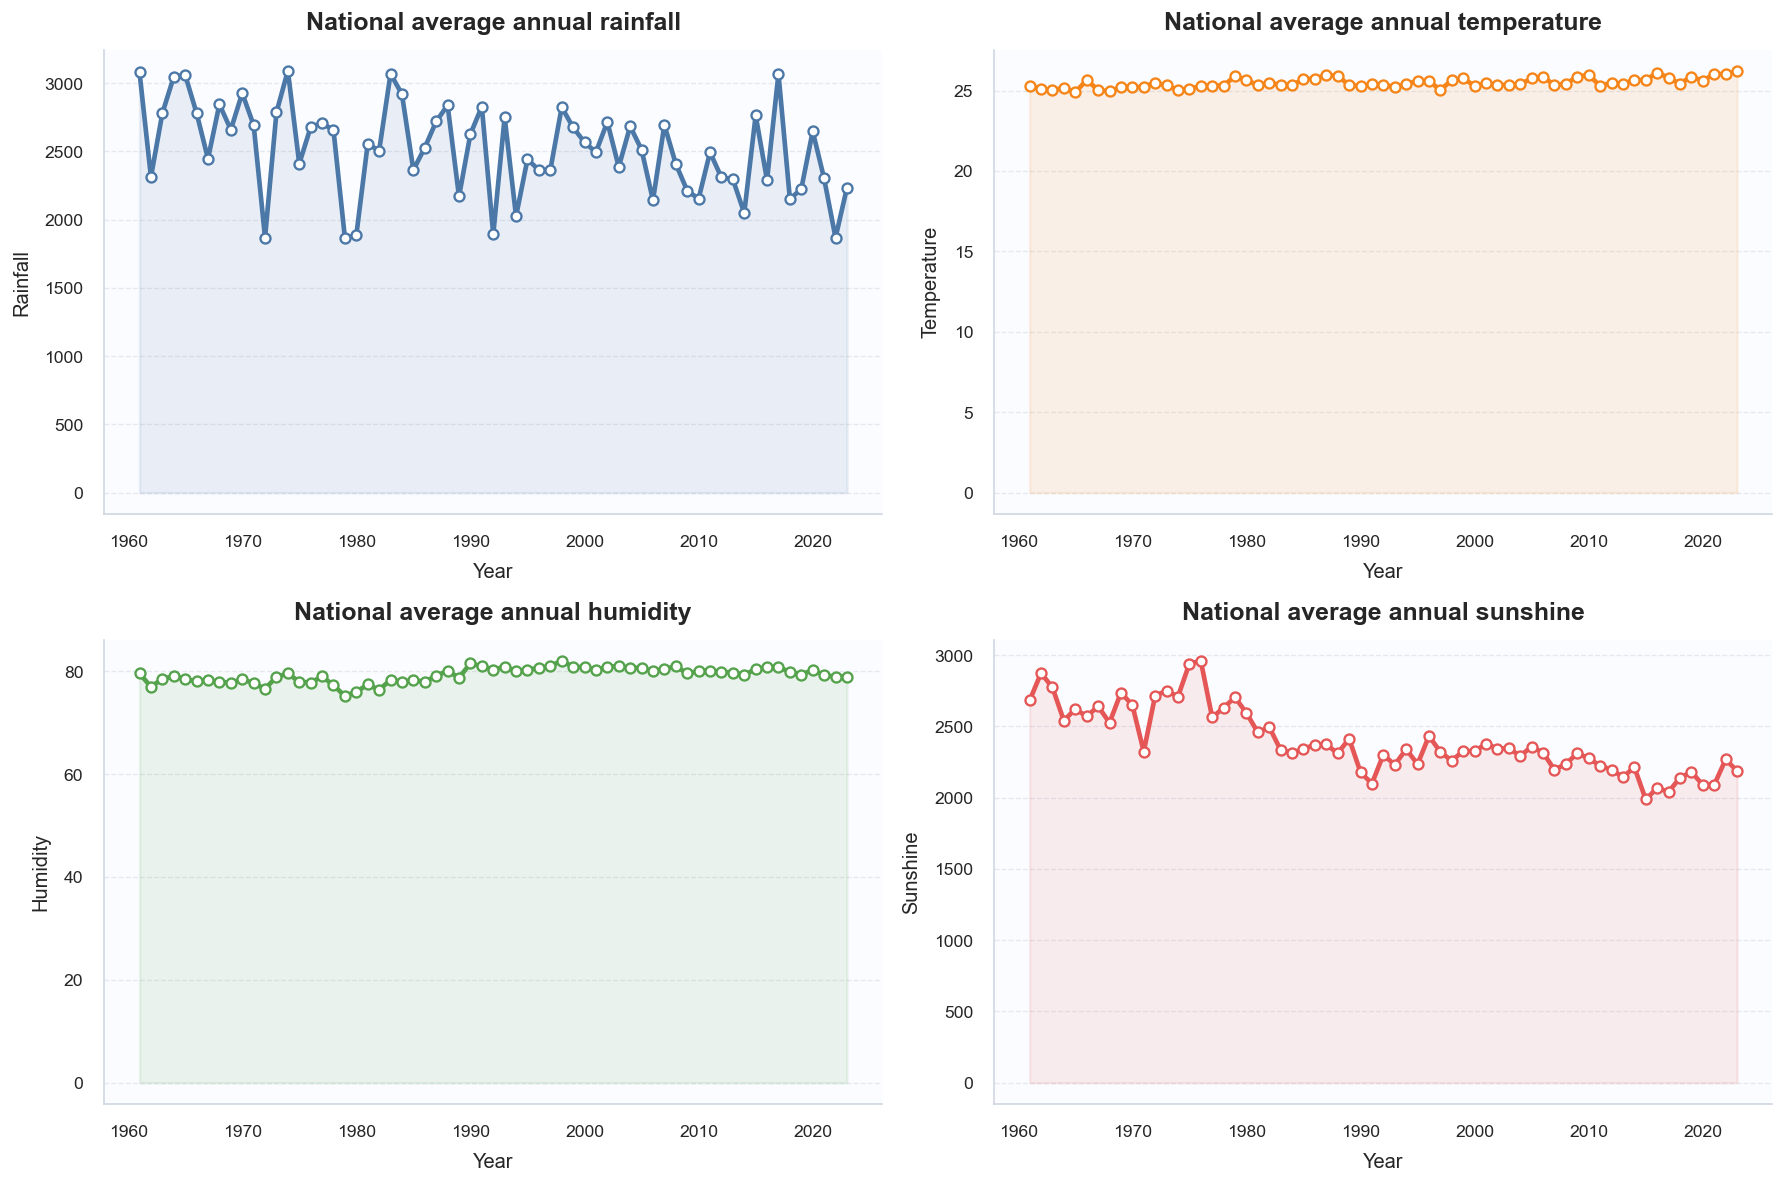

In [23]:
##EDA: time-series plots
##National annual trends
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

trend_specs = [
    ("rainfall_mean", "National average annual rainfall", "#4C78A8", "Rainfall"),
    ("temperature_mean", "National average annual temperature", "#F58518", "Temperature"),
    ("humidity_mean", "National average annual humidity", "#54A24B", "Humidity"),
    ("sunshine_mean", "National average annual sunshine", "#E45756", "Sunshine"),
]

for ax, (col, title, color, ylabel) in zip(axes.flatten(), trend_specs):
    ax.plot(
        national_annual["year"], national_annual[col],
        marker="o", color=color, linewidth=2.8,
        markerfacecolor="white", markeredgewidth=1.4, markeredgecolor=color
    )
    ax.fill_between(national_annual["year"], national_annual[col], color=color, alpha=0.10)
    polish_ax(ax, title, "Year", ylabel)

finish_figure(fig, "results/figures/national_annual_trends.png")

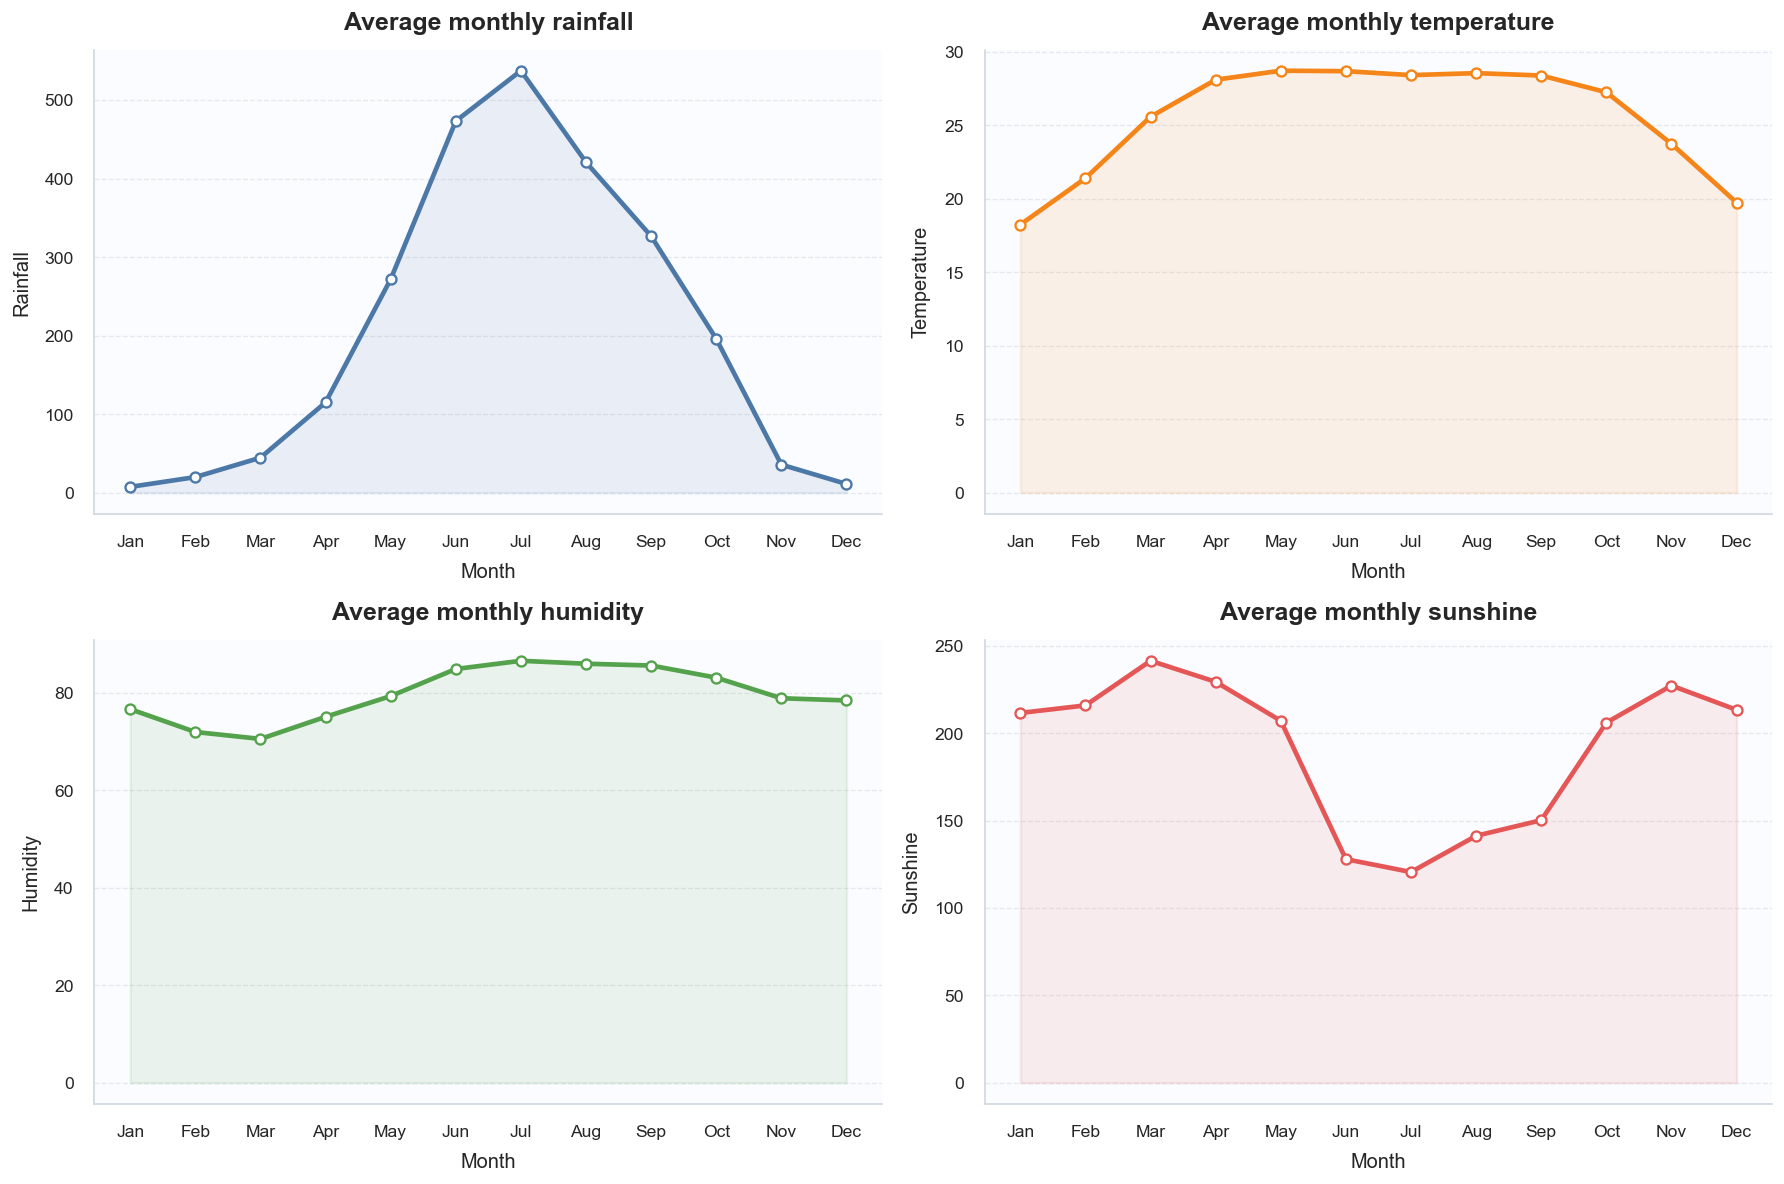

In [24]:
###National monthly climatology
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

clim_specs = [
    ("rainfall_mean", "Average monthly rainfall", "#4C78A8", "Rainfall"),
    ("temperature_mean", "Average monthly temperature", "#F58518", "Temperature"),
    ("humidity_mean", "Average monthly humidity", "#54A24B", "Humidity"),
    ("sunshine_mean", "Average monthly sunshine", "#E45756", "Sunshine"),
]

for ax, (col, title, color, ylabel) in zip(axes.flatten(), clim_specs):
    ax.plot(
        monthly_climatology["month"], monthly_climatology[col],
        marker="o", color=color, linewidth=2.8,
        markerfacecolor="white", markeredgewidth=1.4, markeredgecolor=color
    )
    ax.fill_between(monthly_climatology["month"], monthly_climatology[col], color=color, alpha=0.10)
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(MONTH_LABELS)
    polish_ax(ax, title, "Month", ylabel)

finish_figure(fig, "results/figures/monthly_climatology_lines.png")

In [28]:
##Selected station time-series plot
fig, axes = plt.subplots(4, 1, figsize=(15, 12.5), sharex=True)

series_specs=[
("rainfall", "Rainfall", "#4C78A8"),
("temperature", "Temperature", "#F58518"),
("humidity", "Humidity", "#54A24B"),
("sunshine", "Sunshine", "#E45756"),
]

for ax, (col, label, color) in zip(axes, series_specs):
ax.plot(
d["date"], d[col],
color=color, linewidth=1.8, alpha=0.95
)
polish_ax(ax, f"{station_name.title()} - {label}", None, label)

fig.suptitle(f"{station_name.title()} station weather series", y=1.02, fontsize=17, fontweight="bold")
finish_figure(fig)

plot_station_series("dhaka", start_date="2010-01-01", end_date="2023-12-31")

IndentationError: expected an indented block after 'for' statement on line 11 (1817643372.py, line 12)

In [29]:
###EDA: heatmaps
###Station × month rainfall heatmap
plt.figure(figsize=(13, 10))
ax = sns.heatmap(
    rain_heat,
    cmap=sns.color_palette("crest", as_cmap=True),
    linewidths=0.4,
    linecolor="white",
    cbar_kws={"label": "Rainfall"},
)

ax.set_xticklabels(MONTH_LABELS, rotation=0)
polish_ax(ax, "Station-wise average monthly rainfall", "Month", "Station")
ax.grid(False)

plt.tight_layout()
plt.savefig("results/figures/station_month_rainfall_heatmap.png", dpi=400, bbox_inches="tight", facecolor="white")
plt.show()

NameError: name 'rain_heat' is not defined

<Figure size 1560x1200 with 0 Axes>

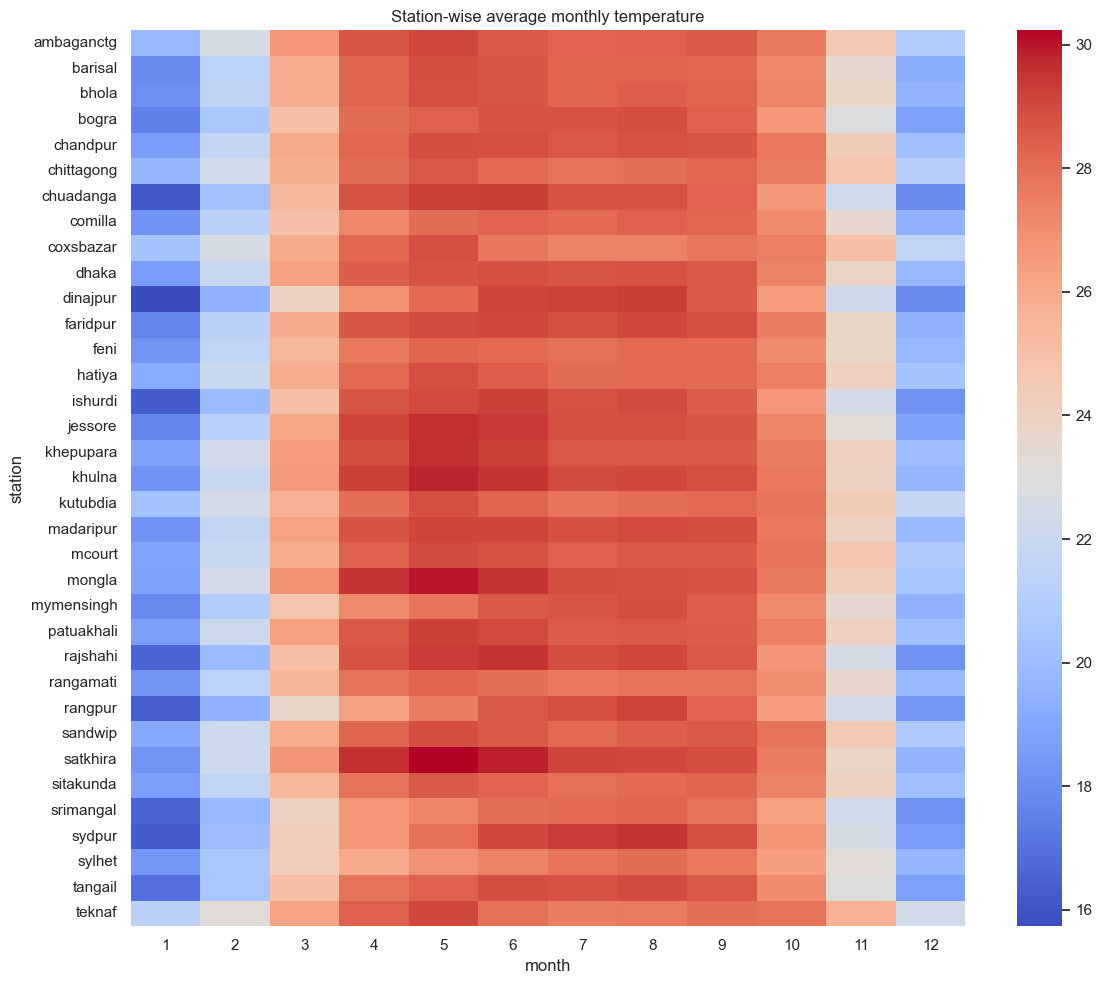

In [28]:
###Station × month temperature heatmap
temp_heat = (
    df_monthly.groupby(["station", "month"])["temperature_mean"]
    .mean()
    .reset_index()
    .pivot(index="station", columns="month", values="temperature_mean")
)

plt.figure(figsize=(12, 10))
sns.heatmap(temp_heat, cmap="coolwarm")
plt.title("Station-wise average monthly temperature")
plt.tight_layout()
plt.savefig("results/figures/station_month_temperature_heatmap.png", dpi=300)
plt.show()

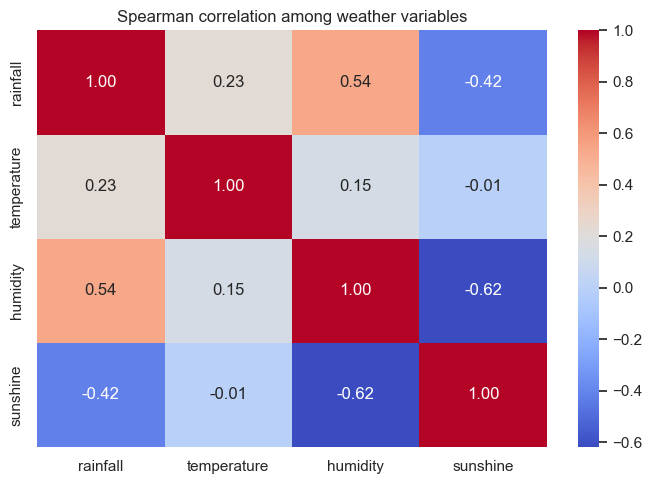

In [29]:
###EDA: correlations
##Overall correlation
corr = df_daily[weather_cols].corr(method="spearman")

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Spearman correlation among weather variables")
plt.tight_layout()
plt.savefig("results/figures/weather_correlation_heatmap.png", dpi=300)
plt.show()

In [30]:
##Seasonal correlation tables
season_corrs = {}
for season_name, g in df_daily.groupby("season"):
    season_corrs[season_name] = g[weather_cols].corr(method="spearman")

season_corrs["monsoon"]


,rainfall,temperature,humidity,sunshine
rainfall,1.000000,-0.493677,0.489134,-0.371860
temperature,-0.493677,1.000000,-0.777730,0.602537
humidity,0.489134,-0.777730,1.000000,-0.668467
sunshine,-0.371860,0.602537,-0.668467,1.000000


In [31]:
##ADF stationarity check
def adf_test_station_monthly(station_name):
    d = df_daily[df_daily["station"] == station_name].copy().sort_values("date")
    d = d.set_index("date")[weather_cols].resample("M").mean().dropna()

    rows = []
    for col in weather_cols:
        series = d[col].dropna()
        result = adfuller(series, autolag="AIC")
        rows.append({
            "station": station_name,
            "variable": col,
            "adf_stat": result[0],
            "p_value": result[1],
            "n_obs": result[3],
            "stationary_at_5pct": result[1] < 0.05
        })
    return pd.DataFrame(rows)

adf_dhaka = adf_test_station_monthly("dhaka")
adf_dhaka

,station,variable,adf_stat,p_value,n_obs,stationary_at_5pct
0,dhaka,rainfall,-6.687015,4.201139e-09,738,True
1,dhaka,temperature,-3.237284,1.792545e-02,735,True
2,dhaka,humidity,-3.295358,1.508726e-02,740,True
3,dhaka,sunshine,-1.971303,2.992959e-01,742,False


In [32]:
adf_dhaka.to_csv("results/tables/adf_dhaka_monthly.csv", index=False)

In [33]:
###Long-term trend analysis
##Trend function
def station_trend_table(df, value_col):
    rows = []

    for station, g in df.groupby("station"):
        g = g.sort_values("year")
        x = g["year"].values.astype(float)
        y = g[value_col].values.astype(float)

        if len(g) < 5:
            continue

        lr = linregress(x, y)
        tau, tau_p = kendalltau(x, y)
        ts_slope, ts_intercept, ts_low, ts_high = theilslopes(y, x, 0.95)

        rows.append({
            "station": station,
            "n_years": len(g),
            "start_year": int(g["year"].min()),
            "end_year": int(g["year"].max()),
            "linear_slope_per_year": lr.slope,
            "linear_slope_per_decade": lr.slope * 10,
            "linear_pvalue": lr.pvalue,
            "r_squared": lr.rvalue ** 2,
            "kendall_tau": tau,
            "kendall_pvalue": tau_p,
            "theil_sen_slope_per_year": ts_slope,
            "theil_sen_slope_per_decade": ts_slope * 10,
            "trend_direction": (
                "increasing" if lr.slope > 0 else
                "decreasing" if lr.slope < 0 else
                "flat"
            ),
            "significant_5pct": lr.pvalue < 0.05
        })

    return pd.DataFrame(rows)
    

In [34]:
###Station-level trends for all four variables
trend_rain = station_trend_table(df_annual, "rainfall_sum")
trend_temp = station_trend_table(df_annual, "temperature_mean")
trend_hum  = station_trend_table(df_annual, "humidity_mean")
trend_sun  = station_trend_table(df_annual, "sunshine_sum")

trend_rain.head()

,station,n_years,start_year,end_year,linear_slope_per_year,linear_slope_per_decade,linear_pvalue,r_squared,kendall_tau,kendall_pvalue,theil_sen_slope_per_year,theil_sen_slope_per_decade,trend_direction,significant_5pct
0,ambaganctg,16,2008,2023,-19.726471,-197.264706,0.497757,0.033454,-0.183333,0.350195,-24.342857,-243.428571,decreasing,False
1,barisal,57,1967,2023,-3.265491,-32.654913,0.272774,0.021826,-0.119712,0.188562,-3.666667,-36.666667,decreasing,False
2,bhola,43,1981,2023,-10.118242,-101.182422,0.039765,0.099111,-0.228255,0.031084,-9.250000,-92.500000,decreasing,True
3,bogra,63,1961,2023,0.641082,6.410820,0.814195,0.000913,0.038481,0.656381,1.181818,11.818182,increasing,False
4,chandpur,47,1977,2023,-12.623381,-126.233811,0.038564,0.091685,-0.158480,0.116785,-7.000000,-70.000000,decreasing,True


In [35]:
trend_rain.to_csv("results/tables/trend_rainfall_station.csv", index=False)
trend_temp.to_csv("results/tables/trend_temperature_station.csv", index=False)
trend_hum.to_csv("results/tables/trend_humidity_station.csv", index=False)
trend_sun.to_csv("results/tables/trend_sunshine_station.csv", index=False)

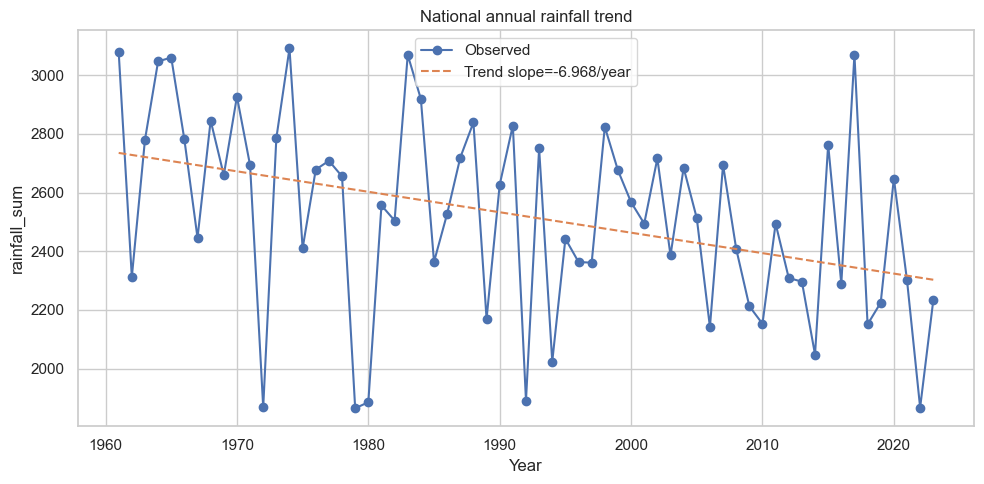

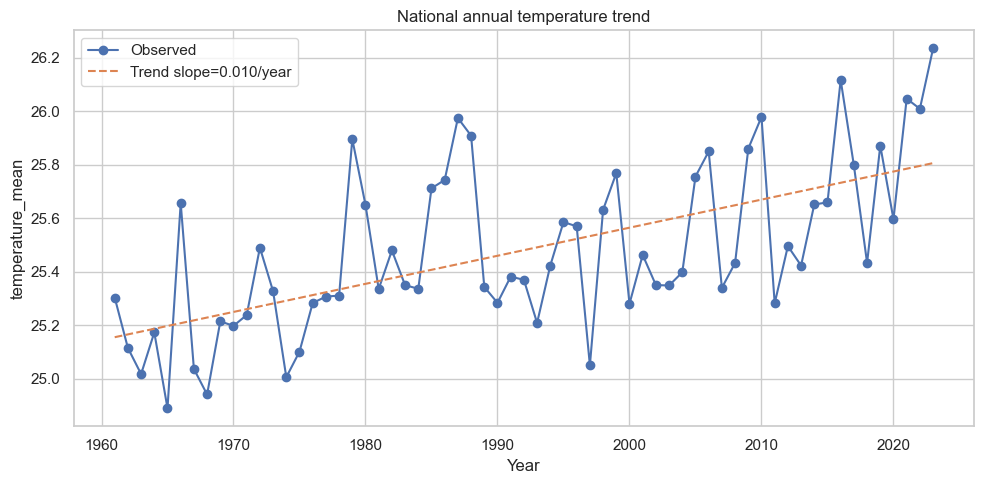

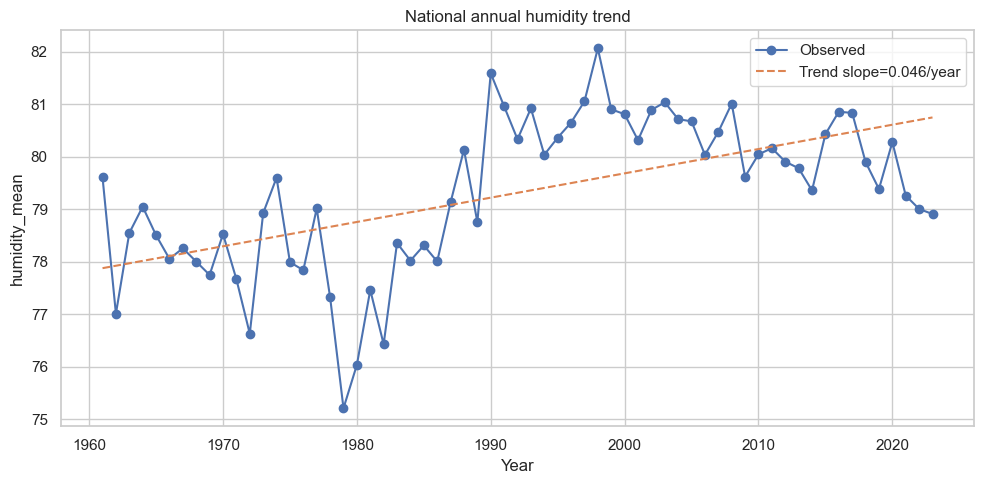

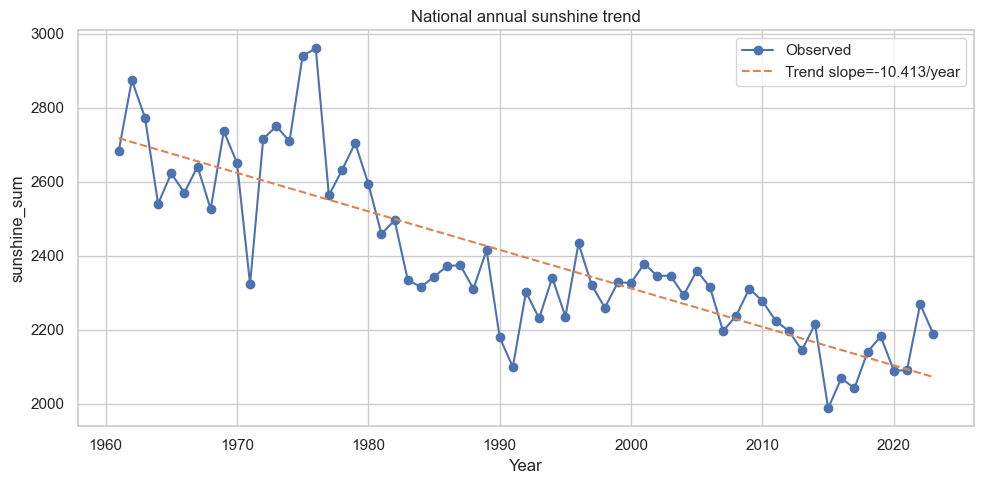

In [36]:
##National trend with fitted line
def plot_national_trend(df, y_col, title, save_name):
    g = df.groupby("year", as_index=False)[y_col].mean()
    x = g["year"].values
    y = g[y_col].values

    lr = linregress(x, y)
    y_hat = lr.intercept + lr.slope * x

    plt.figure(figsize=(10, 5))
    plt.plot(x, y, marker="o", label="Observed")
    plt.plot(x, y_hat, linestyle="--", label=f"Trend slope={lr.slope:.3f}/year")
    plt.title(title)
    plt.xlabel("Year")
    plt.ylabel(y_col)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"results/figures/{save_name}", dpi=300)
    plt.show()

plot_national_trend(df_annual, "rainfall_sum", "National annual rainfall trend", "national_rainfall_trend.png")
plot_national_trend(df_annual, "temperature_mean", "National annual temperature trend", "national_temperature_trend.png")
plot_national_trend(df_annual, "humidity_mean", "National annual humidity trend", "national_humidity_trend.png")
plot_national_trend(df_annual, "sunshine_sum", "National annual sunshine trend", "national_sunshine_trend.png")

In [37]:
###Seasonal trends
seasonal_yearly = (
    df_monthly.groupby(["year", "season"], as_index=False)
    .agg(
        rainfall_sum=("rainfall_sum", "mean"),
        temperature_mean=("temperature_mean", "mean"),
        humidity_mean=("humidity_mean", "mean"),
        sunshine_sum=("sunshine_sum", "mean")
    )
)

seasonal_yearly.head()

,year,season,rainfall_sum,temperature_mean,humidity_mean,sunshine_sum
0,1961,monsoon,595.450000,27.843220,87.158280,170.919500
1,1961,post_monsoon,105.600000,24.858667,79.312796,257.364000
2,1961,pre_monsoon,140.361333,27.753814,75.974552,246.285333
3,1961,winter,21.656667,19.672314,73.137956,248.335333
4,1962,monsoon,425.850000,27.911548,86.512419,167.562500


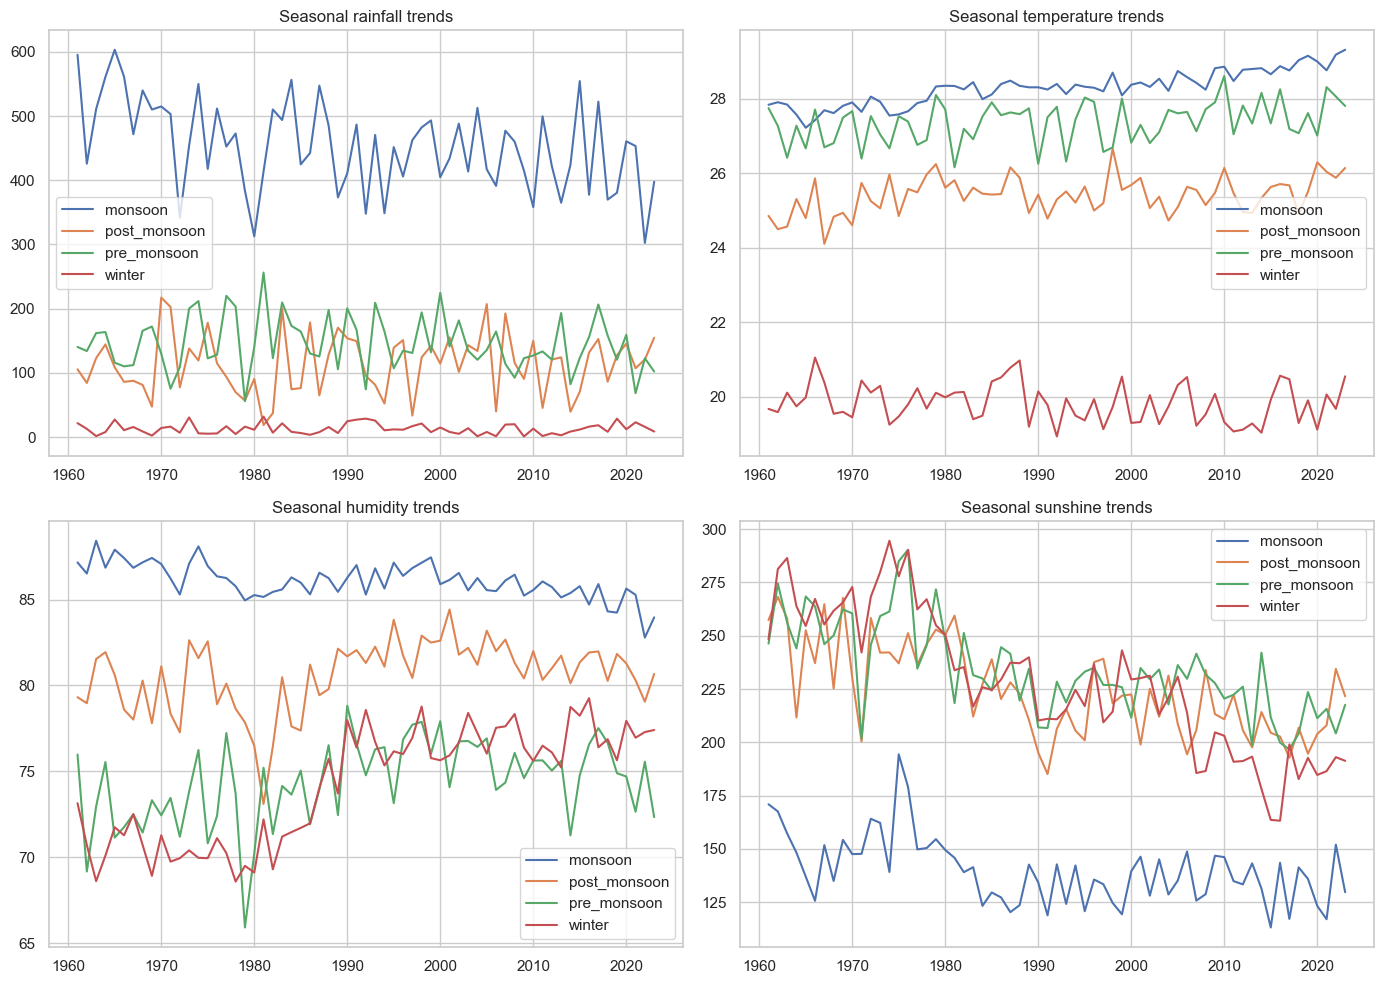

In [38]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for season_name, g in seasonal_yearly.groupby("season"):
    axes[0, 0].plot(g["year"], g["rainfall_sum"], label=season_name)
    axes[0, 1].plot(g["year"], g["temperature_mean"], label=season_name)
    axes[1, 0].plot(g["year"], g["humidity_mean"], label=season_name)
    axes[1, 1].plot(g["year"], g["sunshine_sum"], label=season_name)

axes[0, 0].set_title("Seasonal rainfall trends")
axes[0, 1].set_title("Seasonal temperature trends")
axes[1, 0].set_title("Seasonal humidity trends")
axes[1, 1].set_title("Seasonal sunshine trends")

for ax in axes.flatten():
    ax.legend()

plt.tight_layout()
plt.savefig("results/figures/seasonal_trends_all_variables.png", dpi=300)
plt.show()


In [39]:
##Extreme-event analysis
if "heavy_rain_day" not in df_daily.columns:
    df_daily["heavy_rain_day"] = (df_daily["rainfall"] >= 50).astype(int)
if "very_heavy_rain_day" not in df_daily.columns:
    df_daily["very_heavy_rain_day"] = (df_daily["rainfall"] >= 100).astype(int)
if "hot_day" not in df_daily.columns:
    df_daily["hot_day"] = (df_daily["temperature"] >= 35).astype(int)
if "high_humidity_day" not in df_daily.columns:
    df_daily["high_humidity_day"] = (df_daily["humidity"] >= 85).astype(int)
if "low_sunshine_day" not in df_daily.columns:
    df_daily["low_sunshine_day"] = (df_daily["sunshine"] <= 2).astype(int)

extreme_annual = (
    df_daily.groupby(["station", "year"], as_index=False)
    .agg(
        heavy_rain_days=("heavy_rain_day", "sum"),
        very_heavy_rain_days=("very_heavy_rain_day", "sum"),
        hot_days=("hot_day", "sum"),
        high_humidity_days=("high_humidity_day", "sum"),
        low_sunshine_days=("low_sunshine_day", "sum")
    )
)

extreme_annual.head()

,station,year,heavy_rain_days,very_heavy_rain_days,hot_days,high_humidity_days,low_sunshine_days
0,ambaganctg,2008,21,8,0,95,66
1,ambaganctg,2009,22,11,0,81,58
2,ambaganctg,2010,12,4,0,75,37
3,ambaganctg,2011,23,8,0,99,58
4,ambaganctg,2012,19,8,0,119,51


In [40]:
extreme_annual.to_csv("results/tables/extreme_annual_station.csv", index=False)

In [41]:
national_extremes = (
    extreme_annual.groupby("year", as_index=False)
    .agg(
        heavy_rain_days=("heavy_rain_days", "mean"),
        very_heavy_rain_days=("very_heavy_rain_days", "mean"),
        hot_days=("hot_days", "mean"),
        high_humidity_days=("high_humidity_days", "mean"),
        low_sunshine_days=("low_sunshine_days", "mean")
    )
)

national_extremes.head()


,year,heavy_rain_days,very_heavy_rain_days,hot_days,high_humidity_days,low_sunshine_days
0,1961,21.2,7.8,0.0,116.8,36.6
1,1962,15.0,4.8,0.2,100.8,36.6
2,1963,16.4,6.6,1.6,121.4,40.0
3,1964,17.6,7.2,2.0,121.8,51.2
4,1965,20.6,7.2,0.0,110.6,50.6


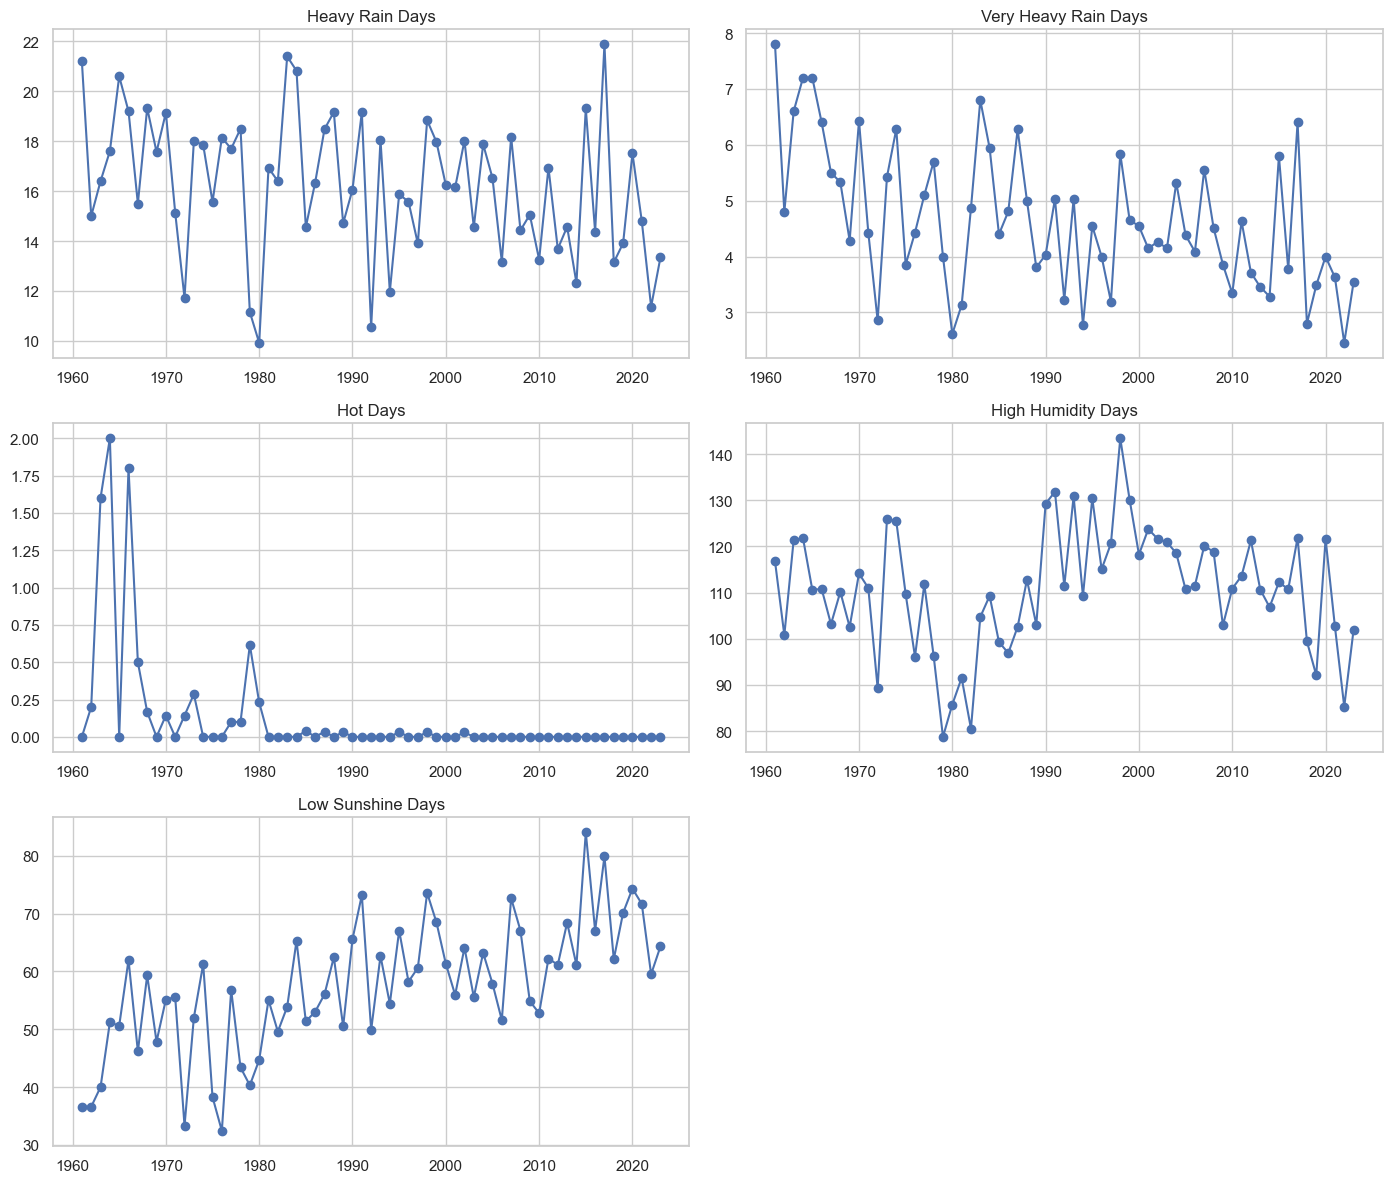

In [42]:
fig, axes = plt.subplots(3, 2, figsize=(14, 12))
axes = axes.flatten()

extreme_cols = [
    "heavy_rain_days",
    "very_heavy_rain_days",
    "hot_days",
    "high_humidity_days",
    "low_sunshine_days"
]

for ax, col in zip(axes, extreme_cols):
    ax.plot(national_extremes["year"], national_extremes[col], marker="o")
    ax.set_title(col.replace("_", " ").title())

# hide last empty subplot
if len(axes) > len(extreme_cols):
    axes[-1].axis("off")

plt.tight_layout()
plt.savefig("results/figures/national_extreme_event_trends.png", dpi=300)
plt.show()

In [43]:
##Define targets and splits
target_cols = [
    "target_rainfall_t1",
    "target_temperature_t1",
    "target_humidity_t1",
    "target_sunshine_t1"
]

base_drop_cols = ["date"] + target_cols
feature_cols = [c for c in df_model.columns if c not in base_drop_cols]

train_df = df_model[df_model["date"] < "2018-01-01"].copy()
valid_df = df_model[(df_model["date"] >= "2018-01-01") & (df_model["date"] < "2021-01-01")].copy()
test_df  = df_model[df_model["date"] >= "2021-01-01"].copy()

print(train_df.shape, valid_df.shape, test_df.shape)

(466104, 73) (38360, 73) (38290, 73)


In [44]:
##One-hot encode station
X_train_raw = train_df[feature_cols].copy()
X_valid_raw = valid_df[feature_cols].copy()
X_test_raw  = test_df[feature_cols].copy()

X_train = pd.get_dummies(X_train_raw, columns=["station"], drop_first=False)
X_valid = pd.get_dummies(X_valid_raw, columns=["station"], drop_first=False)
X_test  = pd.get_dummies(X_test_raw, columns=["station"], drop_first=False)

X_train, X_valid = X_train.align(X_valid, join="left", axis=1, fill_value=0)
X_train, X_test  = X_train.align(X_test, join="left", axis=1, fill_value=0)

y_train = train_df[target_cols].copy()
y_valid = valid_df[target_cols].copy()
y_test  = test_df[target_cols].copy()

print(X_train.shape, y_train.shape)


(466104, 102) (466104, 4)


In [45]:
##Evaluation helpers
def smape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2
    denom = np.where(denom == 0, 1e-8, denom)
    return np.mean(np.abs(y_true - y_pred) / denom) * 100

def evaluate_regression(y_true_df, y_pred_df, model_name):
    rows = []
    for col in y_true_df.columns:
        yt = y_true_df[col].values
        yp = y_pred_df[col].values
        rows.append({
            "model": model_name,
            "target": col,
            "MAE": mean_absolute_error(yt, yp),
            "RMSE": np.sqrt(mean_squared_error(yt, yp)),
            "R2": r2_score(yt, yp),
            "SMAPE": smape(yt, yp)
        })
    return pd.DataFrame(rows)

